In [1]:
import os
import json
import random
from tqdm import tqdm

In [2]:
with open("prompts.json", "r") as f:
    prompts = json.load(f)

In [3]:
len(prompts)

35666

In [4]:
lambdas = [lambda x: json.loads(x.split("```json")[1].replace("```", "")), 
           lambda x: json.loads('[' + x.strip().strip(',') + ']'), 
           lambda x: json.loads('[' + x.strip().strip(",")), 
           lambda x: json.loads(x.strip().strip(",") + ']')]

In [5]:
processed_prompts = {}
count = 0
for key in prompts.keys():
    loaded_dict = None
    for lambd in lambdas:
        try:
            loaded_dict = lambd(prompts[key])
            processed_prompts[key] = loaded_dict
        except Exception as e:
            pass

    if not loaded_dict:
        # print(key)
        count += 1
            
print(count)

555


In [7]:
len(processed_prompts.keys())

35114

In [8]:
set([len(processed_prompts[key]) for key in processed_prompts.keys()])

{0, 1, 9, 10, 11, 12, 13}

In [ ]:
with open("processed_prompts.json", "w") as f:
    json.dump(processed_prompts, f)

In [6]:
len(processed_prompts)

35114

In [10]:
data = []
failed = []
for video_id in tqdm(os.listdir("/home/user/datasets/processed_celebs_data/")):
    optical_images = []
    for img in os.listdir(os.path.join("/home/user/datasets/processed_celebs_data/", video_id)):
        if "optical" in img:
            optical_images.append(img)
    try:
        selected_images = random.choices(optical_images, k=min(20, len(optical_images)))
        prompt = processed_prompts[video_id][0]["prompt"]
        negative_prompt = processed_prompts[video_id][0]["negative_prompt"]
        for img in selected_images:
            prev_img = img.split(".")[0].split("_")[-2] + ".jpg"
            curr_img = img.split(".")[0].split("_")[-1] + ".jpg"
            if type(negative_prompt) == list:
                negative_prompt = ", ".join(negative_prompt)
            elif negative_prompt == None:
                negative_prompt = ""
            data.append({"video_id": video_id, 
                        "prompt": prompt, 
                        "negative_prompt": negative_prompt, 
                        "prev_img_path": os.path.join("/home/user/datasets/processed_celebs_data/", video_id, prev_img), 
                        "curr_img_path": os.path.join("/home/user/datasets/processed_celebs_data/", video_id, curr_img),
                        "optical_flow_path": os.path.join("/home/user/datasets/processed_celebs_data/", video_id, img)})
    except Exception as e:
        failed.append(video_id)
        continue


  6%|▌         | 2194/35666 [00:00<00:15, 2227.66it/s]

100%|██████████| 35666/35666 [00:16<00:00, 2114.33it/s]


In [11]:
len(data), len(failed)

(656380, 2826)

In [12]:
data[2]

{'video_id': '4I-f_G1nBww_7_0',
 'prompt': 'man with black hair, wearing earrings, singing with closed eyes, blue stage lights, close-up shot, performance vibe, blurred background, soft focus',
 'negative_prompt': 'blurry, low resolution, watermark, text',
 'prev_img_path': '/home/user/datasets/processed_celebs_data/4I-f_G1nBww_7_0/34.jpg',
 'curr_img_path': '/home/user/datasets/processed_celebs_data/4I-f_G1nBww_7_0/35.jpg',
 'optical_flow_path': '/home/user/datasets/processed_celebs_data/4I-f_G1nBww_7_0/optical_flow_34_35.jpg'}

In [13]:
with open("temporalnet2_celebs_single_prompt_20.jsonl", "w") as f:
    for d in data:
        json.dump(d, f)
        f.write("\n")

In [14]:
img.split(".")[0].split("_")[-1], img.split(".")[0].split("_")[-2]

('126', '125')

In [ ]:
import collections
collections.Counter(diff)

In [15]:
img

'optical_flow_125_126.jpg'

In [17]:
from PIL import Image
img = Image.open("/home/user/datasets/processed_celebs_data/TqNaJxRC9NM_1/optical_flow_49_51.jpg")



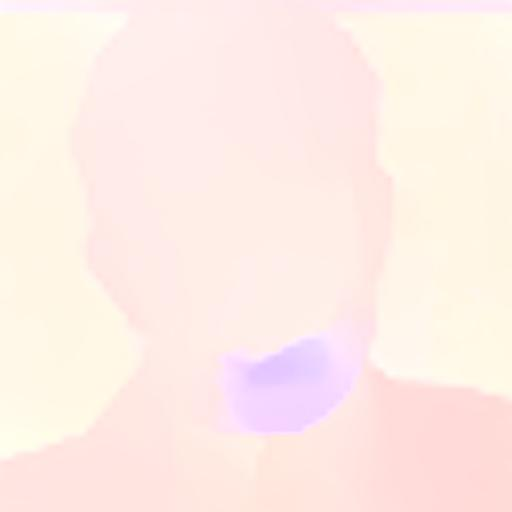

In [18]:
from IPython.display import Image
Image(filename='/home/user/datasets/processed_celebs_data/TqNaJxRC9NM_1/optical_flow_49_51.jpg') 

In [ ]:
random.choices(list(range(len(data))), k=2)

In [19]:
data[155318]

{'video_id': '3iRl9GRYVXY_3_0',
 'prompt': 'bald man with bushy eyebrows and pointy nose, wearing a Hawaiian shirt, sitting at a table, talking, focused expression, warm indoor lighting, shallow depth of field, realistic style',
 'negative_prompt': 'blurry, low resolution, watermark, text',
 'prev_img_path': '/home/user/datasets/processed_celebs_data/3iRl9GRYVXY_3_0/66.jpg',
 'curr_img_path': '/home/user/datasets/processed_celebs_data/3iRl9GRYVXY_3_0/70.jpg',
 'optical_flow_path': '/home/user/datasets/processed_celebs_data/3iRl9GRYVXY_3_0/optical_flow_66_70.jpg'}

In [ ]:
data[54915]